# CatBoost + Text OOF Feature v1

Bu notebook sıfırdan oluşturulmuş deney notebook'udur.

Ana fikir:
- `mentor_feedback_text` doğrudan CatBoost'a verilmez.
- Text için ayrı bir TF-IDF + Ridge modeli kurulur.
- Bu text modelinin OOF tahmini `text_model_pred` olarak CatBoost'a numeric feature şeklinde eklenir.
- Elle ağır katsayılı feature'lar azaltılır.
- CatBoost native categorical kullanılır.
- Submission `results/catboost_text_oof_feature_v1_submission.csv` olarak kaydedilir.

Dosya yolları bilinçli olarak değiştirilmedi:

```python
TRAIN_PATH = "train.csv"
TEST_PATH = "test_x.csv"
```


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from scipy import sparse

from catboost import CatBoostRegressor

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_STATE = 42

TRAIN_PATH = "train_df_with_nlp.csv"
TEST_PATH = "test_df_with_nlp.csv"

TARGET = "career_success_score"
ID_COL = "student_id"

RESULTS_DIR = Path("results2")
RESULTS_DIR.mkdir(exist_ok=True)

RUN_NAME = "catboost_text_oof_feature_v1"


In [31]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

assert TARGET in train_df.columns, f"{TARGET} train içinde yok."
assert ID_COL in train_df.columns, f"{ID_COL} train içinde yok."
assert ID_COL in test_df.columns, f"{ID_COL} test içinde yok."

print("Target min/max:", train_df[TARGET].min(), train_df[TARGET].max())
display(train_df.head())
display(test_df.head())


Train shape: (10000, 47)
Test shape : (10000, 46)
Target min/max: 0.0 100.0


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,career_success_score,mentor_feedback_text
0,STU_000001,2021,21,2021,Computer Engineering,Tier 4,3.17,62.54,77.31,0,DevOps Engineer,73.28,71.11,52.91,84.980000,81.77,62.710000,71.570000,63.041897,69.952625,81.90,0,3,11.0,0,0,0,65.54,18,1.85,10.0,86.58,42.06,40.57,50.29,79.83,44.14,62.70,58.84,3,1,24,0,photography,LinkedIn,86.78,Proje kalitesi ve makine öğrenimi konusundaki ...
1,STU_000002,2024,20,2024,Computer Engineering,Tier 4,3.24,75.10,87.13,3,Backend Developer,63.12,78.90,61.81,37.450740,65.54,69.944694,60.830000,64.510000,57.940000,24.68,0,0,NaN,1,1,0,54.48,7,1.22,1.0,33.34,65.39,82.99,67.43,43.60,22.05,42.32,40.54,2,0,46,5,reading,YouTube,46.16,Kodlama ve problem çözme becerileri gelişmekte...
2,STU_000003,2024,28,2024,Electrical Electronics Engineering,Tier 4,3.00,68.53,95.64,1,Frontend Developer,100.00,86.44,83.62,85.440000,87.18,80.580000,96.433149,62.220000,81.750000,78.92,2,0,0.0,2,0,0,75.10,4,12.12,2.0,61.37,52.25,43.06,20.19,48.62,65.64,47.27,82.56,1,2,46,5,cinema,Reddit,84.08,İleri düzey frontend geliştirme becerileri ile...
3,STU_000004,2019,22,2018,Computer Engineering,Tier 1,2.82,54.85,77.80,2,Backend Developer,99.08,72.15,77.15,89.214871,69.49,85.751415,72.860000,73.680000,54.080000,54.93,0,1,9.0,0,1,0,82.40,4,2.96,3.0,45.15,24.12,32.06,28.00,59.84,3.89,78.69,85.05,2,4,49,7,running,Reddit,89.97,Güçlü bir kodlama yeteneği ve backend geliştir...
4,STU_000005,2026,22,2026,Computer Engineering,Tier 3,2.28,72.25,71.97,1,Product Analyst,92.65,91.15,84.51,70.700000,74.11,80.620000,86.830000,80.340000,87.560000,72.85,2,0,NaN,2,0,0,48.02,14,0.97,12.0,74.86,74.83,71.82,65.14,63.30,52.86,27.22,84.29,1,0,119,13,football,X,92.46,Ürün analizi alanına olan tutkusu ve makine öğ...


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,mentor_feedback_text
0,STU_010001,2025,23,2025,Computer Engineering,Tier 4,2.59,45.27,79.11,2,Frontend Developer,42.60,61.53,61.17,34.780000,39.570000,59.61,39.143557,43.540000,52.800000,40.83,1,2,14.0,1,0,0,92.14,8,NaN,NaN,15.41,52.16,62.90,41.79,51.08,90.02,81.33,30.54,6,2,46,6,gaming,YouTube,Öğrencinin proje çalışmasında dikkat çekici bi...
1,STU_010002,2023,23,2022,Electrical Electronics Engineering,Tier 3,3.12,66.30,70.58,1,DevOps Engineer,71.63,95.42,81.59,78.360000,79.410000,74.65,60.360000,84.594122,66.284347,31.24,1,1,5.0,1,2,0,40.16,7,3.64,0.0,43.73,67.56,43.15,83.47,38.26,82.78,82.78,42.37,1,0,4,0,football,TikTok,"Bu öğrenci, problem çözme ve veri yapıları kon..."
2,STU_010003,2025,20,2025,Computer Engineering,Tier 3,3.48,75.45,67.93,0,Data Scientist,66.04,62.71,67.52,89.176084,58.108534,78.01,69.610000,66.840000,54.060000,26.53,1,1,2.0,3,0,0,59.12,8,NaN,NaN,14.96,68.73,71.74,64.96,88.49,51.79,63.30,66.01,4,1,66,3,cinema,Instagram,Öğrencinin veri bilimi konusundaki ilgisi ve g...
3,STU_010004,2020,26,2019,Software Engineering,Tier 2,2.92,45.58,83.95,0,Data Analyst,91.53,67.55,75.47,66.948792,62.822398,66.92,94.010000,64.990000,61.700000,82.96,1,0,0.0,0,1,0,73.90,9,3.18,3.0,NaN,52.79,84.60,79.40,76.32,90.89,46.64,82.60,3,2,42,2,chess,LinkedIn,Son derece etkileyici bir başarıya imza atan b...
4,STU_010005,2024,21,2024,Computer Engineering,Tier 3,2.85,63.08,84.18,1,Software Developer,70.82,70.65,65.16,62.290000,70.590000,54.44,80.420000,41.970000,63.230000,79.70,2,1,6.0,1,1,0,79.54,6,2.04,6.0,58.00,33.37,33.40,77.29,48.09,42.78,43.30,39.65,3,1,25,0,reading,TikTok,Öğrencinin yazılım geliştirme alanındaki çalış...


In [32]:
print("Train missing values:")
display(train_df.isna().sum()[train_df.isna().sum() > 0].sort_values(ascending=False))

print("\nTest missing values:")
display(test_df.isna().sum()[test_df.isna().sum() > 0].sort_values(ascending=False))


Train missing values:


internship_duration_months        1657
english_exam_score                 953
github_avg_stars                   910
open_source_contribution_count     910
hr_interview_score                 780
linkedin_profile_score             668
portfolio_score                    364
dtype: int64


Test missing values:


internship_duration_months        1586
english_exam_score                 944
github_avg_stars                   895
open_source_contribution_count     895
hr_interview_score                 759
linkedin_profile_score             680
portfolio_score                    382
dtype: int64

In [ ]:
print("Train application_year distribution:")
display(train_df["application_year"].value_counts(normalize=True).sort_index())

print("Test application_year distribution:")
display(test_df["application_year"].value_counts(normalize=True).sort_index())

year_dist = pd.DataFrame({
    "train_ratio": train_df["application_year"].value_counts(normalize=True).sort_index(),
    "test_ratio": test_df["application_year"].value_counts(normalize=True).sort_index()
})
year_dist["test_train_ratio"] = year_dist["test_ratio"] / year_dist["train_ratio"]
display(year_dist)


Train application_year distribution:


application_year
2019    0.1289
2020    0.1329
2021    0.1270
2022    0.1293
2023    0.1312
2024    0.1319
2025    0.1191
2026    0.0997
Name: proportion, dtype: float64

Test application_year distribution:


application_year
2019    0.0403
2020    0.0507
2021    0.0691
2022    0.0881
2023    0.1298
2024    0.1994
2025    0.2197
2026    0.2029
Name: proportion, dtype: float64

,train_ratio,test_ratio,test_train_ratio
application_year,,,
2019,0.1289,0.0403,0.312645
2020,0.1329,0.0507,0.381490
2021,0.1270,0.0691,0.544094
2022,0.1293,0.0881,0.681361
2023,0.1312,0.1298,0.989329
2024,0.1319,0.1994,1.511751
2025,0.1191,0.2197,1.844668
2026,0.0997,0.2029,2.035105


## Missing value işlemleri

Mantık:
- Missing flag'ler önce oluşturulur.
- Fill değerleri train üzerinden öğrenilir.
- Test'e train'den öğrenilen mean/median/grup median uygulanır.


In [33]:
def add_missing_flags(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    missing_cols = [
        "english_exam_score",
        "internship_duration_months",
        "portfolio_score",
        "github_avg_stars",
        "open_source_contribution_count",
        "linkedin_profile_score",
        "hr_interview_score"
    ]

    for col in missing_cols:
        if col in df.columns:
            df[f"{col}_was_missing"] = df[col].isna().astype(int)

    return df


def fill_missing_values(train: pd.DataFrame, test: pd.DataFrame):
    train = train.copy()
    test = test.copy()

    mean_cols = [
        "english_exam_score",
        "linkedin_profile_score",
        "hr_interview_score",
        "portfolio_score"
    ]

    median_cols = [
        "github_avg_stars",
        "open_source_contribution_count"
    ]

    for col in mean_cols:
        if col in train.columns:
            fill_value = train[col].mean()
            train[col] = train[col].fillna(fill_value)
            test[col] = test[col].fillna(fill_value)

    for col in median_cols:
        if col in train.columns:
            fill_value = train[col].median()
            train[col] = train[col].fillna(fill_value)
            test[col] = test[col].fillna(fill_value)

    # internship_duration_months: internship_count grubuna göre train median
    col = "internship_duration_months"
    group_col = "internship_count"

    if col in train.columns and group_col in train.columns:
        global_median = train[col].median()
        group_medians = train.groupby(group_col)[col].median()

        train[col] = train.apply(
            lambda row: group_medians.get(row[group_col], global_median)
            if pd.isna(row[col]) else row[col],
            axis=1
        )

        test[col] = test.apply(
            lambda row: group_medians.get(row[group_col], global_median)
            if pd.isna(row[col]) else row[col],
            axis=1
        )

        train[col] = train[col].fillna(global_median)
        test[col] = test[col].fillna(global_median)

    if "mentor_feedback_text" in train.columns:
        train["mentor_feedback_text"] = train["mentor_feedback_text"].fillna("")
        test["mentor_feedback_text"] = test["mentor_feedback_text"].fillna("")

    return train, test


## Balanced numeric feature engineering

Bu sürümde ağır elle katsayılandırılmış feature'lar yerine daha kontrollü sinyaller kullanılır:

- Ortalama / std / range
- Rol uyum skoru
- Log dönüşümleri
- Oranlar
- `/100` ile ölçeklenmiş interaction'lar


In [ ]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ------------------------------------------------------------
    # Graduation / temporal
    # ------------------------------------------------------------
    df["years_since_graduation"] = df["application_year"] - df["graduation_year"]
    df["age_at_graduation"] = df["age"] - df["years_since_graduation"]

    # university_tier kategorik olarak kalır; ayrıca ordinal rank da eklenir.
    tier_rank_map = {
        "Tier 1": 4,
        "Tier 2": 3,
        "Tier 3": 2,
        "Tier 4": 1
    }
    if "university_tier" in df.columns:
        df["university_tier_rank"] = (
            df["university_tier"].map(tier_rank_map).fillna(0).astype(int)
        )

    # ------------------------------------------------------------
    # Technical skill summaries
    # ------------------------------------------------------------
    technical_skill_cols = [
        "coding_score",
        "problem_solving_score",
        "data_structures_score",
        "sql_score",
        "machine_learning_score",
        "backend_score",
        "frontend_score",
        "cloud_score",
        "devops_score"
    ]

    df["technical_skill_mean"] = df[technical_skill_cols].mean(axis=1)
    df["technical_skill_std"] = df[technical_skill_cols].std(axis=1)
    df["technical_skill_min"] = df[technical_skill_cols].min(axis=1)
    df["technical_skill_max"] = df[technical_skill_cols].max(axis=1)
    df["technical_skill_range"] = (
        df["technical_skill_max"] - df["technical_skill_min"]
    )

    df["data_ai_score"] = df[
        [
            "sql_score",
            "machine_learning_score",
            "problem_solving_score",
            "data_structures_score",
            "coding_score"
        ]
    ].mean(axis=1)

    df["software_engineering_score"] = df[
        [
            "backend_score",
            "frontend_score",
            "cloud_score",
            "devops_score",
            "coding_score",
            "data_structures_score"
        ]
    ].mean(axis=1)

    df["cloud_devops_score"] = df[
        ["cloud_score", "devops_score", "backend_score"]
    ].mean(axis=1)

    df["core_cs_score"] = df[
        ["coding_score", "problem_solving_score", "data_structures_score"]
    ].mean(axis=1)

    # ------------------------------------------------------------
    # Role-specific skill fit
    # ------------------------------------------------------------
    role = df["target_role"].fillna("").astype(str).str.lower()

    df["role_skill_fit_score"] = df["technical_skill_mean"]

    role_score_specs = [
        (role.eq("backend developer"), ["backend_score", "coding_score", "data_structures_score", "problem_solving_score"]),
        (role.eq("frontend developer"), ["frontend_score", "coding_score", "presentation_score"]),
        (role.eq("software developer"), ["coding_score", "data_structures_score", "problem_solving_score", "backend_score", "frontend_score"]),
        (role.eq("data scientist"), ["machine_learning_score", "sql_score", "problem_solving_score", "data_structures_score", "coding_score"]),
        (role.eq("data analyst"), ["sql_score", "problem_solving_score", "machine_learning_score", "presentation_score"]),
        (role.eq("ai engineer"), ["machine_learning_score", "coding_score", "problem_solving_score", "data_structures_score", "cloud_score"]),
        (role.eq("mlops engineer"), ["machine_learning_score", "devops_score", "cloud_score", "coding_score"]),
        (role.eq("cloud engineer"), ["cloud_score", "devops_score", "backend_score"]),
        (role.eq("devops engineer"), ["devops_score", "cloud_score", "backend_score"]),
        (role.eq("cybersecurity analyst"), ["problem_solving_score", "backend_score", "devops_score", "cloud_score"]),
        (role.eq("product analyst"), ["sql_score", "presentation_score", "communication_score", "problem_solving_score"]),
    ]

    for mask, cols in role_score_specs:
        df.loc[mask, "role_skill_fit_score"] = df.loc[mask, cols].mean(axis=1)

    df["role_fit_minus_technical_mean"] = (
        df["role_skill_fit_score"] - df["technical_skill_mean"]
    )

    # ------------------------------------------------------------
    # Soft skills
    # ------------------------------------------------------------
    soft_skill_cols = [
        "communication_score",
        "teamwork_score",
        "leadership_score",
        "presentation_score",
        "linkedin_profile_score",
        "cv_quality_score",
        "hr_interview_score"
    ]

    df["soft_skill_mean"] = df[soft_skill_cols].mean(axis=1)
    df["soft_skill_std"] = df[soft_skill_cols].std(axis=1)
    df["communication_presentation_mean"] = df[
        ["communication_score", "presentation_score"]
    ].mean(axis=1)

    # ------------------------------------------------------------
    # Project / portfolio / GitHub
    # ------------------------------------------------------------
    df["project_count_total"] = (
        df["real_client_project_count"] + df["freelance_project_count"]
    )

    df["portfolio_project_quality_mean"] = df[
        ["portfolio_score", "project_quality_score", "cv_quality_score"]
    ].mean(axis=1)

    df["portfolio_project_quality_interaction"] = (
        df["portfolio_score"] * df["project_quality_score"] / 100
    )

    df["project_quality_x_real_client_log"] = (
        df["project_quality_score"] * np.log1p(df["real_client_project_count"])
    )

    df["project_quality_x_project_count_log"] = (
        df["project_quality_score"] * np.log1p(df["project_count_total"])
    )

    df["github_activity_log"] = np.log1p(
        df["github_repo_count"] * df["github_avg_stars"]
    )

    df["github_impact_log"] = (
        np.log1p(df["github_repo_count"])
        + np.log1p(df["github_avg_stars"])
        + np.log1p(df["open_source_contribution_count"])
    )

    df["github_per_repo_quality"] = (
        df["github_avg_stars"] / (df["github_repo_count"] + 1)
    )

    df["github_open_source_intensity"] = (
        df["open_source_contribution_count"] / (df["github_repo_count"] + 1)
    )

    df["profile_visibility_mean"] = df[
        ["linkedin_profile_score", "portfolio_score", "cv_quality_score"]
    ].mean(axis=1)

    df["portfolio_x_linkedin"] = (
        df["portfolio_score"] * df["linkedin_profile_score"] / 100
    )

    # ------------------------------------------------------------
    # Experience / hackathon / learning
    # ------------------------------------------------------------
    df["experience_count_total"] = (
        df["real_client_project_count"]
        + df["internship_count"]
        + df["freelance_project_count"]
        + df["hackathon_count"]
        + df["certification_count"]
        + df["bootcamp_count"]
    )

    df["experience_count_log"] = np.log1p(df["experience_count_total"])

    df["internship_months_per_internship"] = (
        df["internship_duration_months"] / (df["internship_count"] + 1)
    )

    df["internship_experience_log"] = (
        np.log1p(df["internship_count"])
        + np.log1p(df["internship_duration_months"])
    )

    df["hackathon_award_rate"] = (
        df["hackathon_awards"] / (df["hackathon_count"] + 1)
    )

    df["hackathon_activity_log"] = (
        np.log1p(df["hackathon_count"]) + np.log1p(df["hackathon_awards"])
    )

    df["learning_count_total"] = (
        df["certification_count"] + df["bootcamp_count"]
    )

    df["learning_activity_log"] = np.log1p(df["learning_count_total"])

    # ------------------------------------------------------------
    # Application / interview funnel
    # ------------------------------------------------------------
    df["interview_conversion_rate"] = (
        df["interviews_attended"] / (df["applications_sent"] + 1)
    )

    df["applications_without_interview"] = (
        df["applications_sent"] - df["interviews_attended"]
    )

    df["log_applications_sent"] = np.log1p(df["applications_sent"])
    df["log_interviews_attended"] = np.log1p(df["interviews_attended"])

    df["interview_score_mean"] = df[
        ["technical_interview_score", "hr_interview_score"]
    ].mean(axis=1)

    df["interview_score_gap"] = (
        df["technical_interview_score"] - df["hr_interview_score"]
    )

    df["technical_interview_x_conversion"] = (
        df["technical_interview_score"] * df["interview_conversion_rate"]
    )

    df["interview_mean_x_conversion"] = (
        df["interview_score_mean"] * df["interview_conversion_rate"]
    )

    # ------------------------------------------------------------
    # Controlled interactions
    # ------------------------------------------------------------
    df["technical_x_project_quality"] = (
        df["technical_skill_mean"] * df["project_quality_score"] / 100
    )

    df["technical_x_portfolio"] = (
        df["technical_skill_mean"] * df["portfolio_score"] / 100
    )

    df["role_fit_x_project_quality"] = (
        df["role_skill_fit_score"] * df["project_quality_score"] / 100
    )

    df["soft_x_technical_interview"] = (
        df["soft_skill_mean"] * df["technical_interview_score"] / 100
    )

    df["soft_x_interview_mean"] = (
        df["soft_skill_mean"] * df["interview_score_mean"] / 100
    )

    df["profile_x_project_quality"] = (
        df["profile_visibility_mean"] * df["project_quality_score"] / 100
    )

    # ------------------------------------------------------------
    # Simple NLP keyword feature'ları
    # Bunlar ana NLP sinyali değil; text_model_pred asıl NLP sinyali olacak.
    # ------------------------------------------------------------
    feedback_lower = (
        df["mentor_feedback_text"]
        .fillna("")
        .astype(str)
        .str.lower()
    )

    df["mentor_feedback_len"] = feedback_lower.str.len()
    df["mentor_feedback_word_count"] = feedback_lower.str.split().str.len()

    tech_keywords = [
        "makine öğrenimi", "veri yapıları", "veri bilimi", "veri analizi",
        "backend", "frontend", "bulut", "yazılım", "açık kaynak",
        "github", "sql", "yapay zeka", "devops", "cloud", "kodlama",
        "problem çözme", "algoritma", "mobil", "siber güvenlik", "data",
        "analist", "mühendis", "developer"
    ]

    soft_keywords = [
        "iletişim", "takım çalışması", "mülakat", "proje", "takım",
        "liderlik", "sunum", "ekip", "zaman yönetimi",
        "analitik düşünme", "yönetim", "ikna"
    ]

    positive_signals = [
        "etkileyici", "güçlü", "dikkat çekici", "dikkat çekiyor",
        "dikkat çeken", "sağlam temel", "yüksek", "başarılı",
        "harika", "potansiyel", "iyi seviyede", "mükemmel",
        "tatmin edici", "beklentileri aşıyor", "yetkin"
    ]

    negative_signals = [
        "faydalı olacaktır", "fazla pratik", "deneyim kazanması",
        "pratik yapması", "geliştirmeli", "eksik", "odaklanmalı",
        "çalışmalı", "yetersiz", "zayıf", "beklentilerin altında",
        "artırmalı", "ihtiyacı var"
    ]

    contrast_words = [
        "ancak", "fakat", "rağmen", "gösterse de",
        "bununla birlikte", "yine de", "yalnız"
    ]

    df["nlp_tech_keyword_count"] = feedback_lower.apply(
        lambda text: sum(keyword in text for keyword in tech_keywords)
    )
    df["nlp_soft_keyword_count"] = feedback_lower.apply(
        lambda text: sum(keyword in text for keyword in soft_keywords)
    )
    df["nlp_positive_signal_count"] = feedback_lower.apply(
        lambda text: sum(signal in text for signal in positive_signals)
    )
    df["nlp_negative_signal_count"] = feedback_lower.apply(
        lambda text: sum(signal in text for signal in negative_signals)
    )
    df["nlp_has_contrast"] = feedback_lower.apply(
        lambda text: int(any(word in text for word in contrast_words))
    )
    df["nlp_sentiment_balance"] = (
        df["nlp_positive_signal_count"] - df["nlp_negative_signal_count"]
    )

    df = df.replace([np.inf, -np.inf], np.nan)

    return df


## Text-only TF-IDF + Ridge OOF prediction

Bu kısım sadece `mentor_feedback_text` ile tahmin üretir.

Üretilen feature'lar:
- `text_model_pred`
- `text_model_pred_centered`
- `text_model_pred_rank`
- `text_model_pred_x_role_fit`


In [ ]:
def build_text_oof_features(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    target_col: str,
    text_col: str = "mentor_feedback_text",
    seed: int = RANDOM_STATE
):
    train_text = train_df[text_col].fillna("").astype(str)
    test_text = test_df[text_col].fillna("").astype(str)
    y_text = train_df[target_col].values

    word_vectorizer = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 3),
        min_df=3,
        max_features=40000,
        sublinear_tf=True,
        lowercase=True
    )

    char_vectorizer = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=3,
        max_features=40000,
        sublinear_tf=True,
        lowercase=True
    )

    print("Fitting word TF-IDF...")
    X_word = word_vectorizer.fit_transform(train_text)
    X_test_word = word_vectorizer.transform(test_text)

    print("Fitting char TF-IDF...")
    X_char = char_vectorizer.fit_transform(train_text)
    X_test_char = char_vectorizer.transform(test_text)

    X_text = sparse.hstack([X_word, X_char]).tocsr()
    X_test_text = sparse.hstack([X_test_word, X_test_char]).tocsr()

    print("Text train matrix:", X_text.shape)
    print("Text test matrix :", X_test_text.shape)

    kf = KFold(n_splits=5, shuffle=True, random_state=seed)

    text_oof = np.zeros(len(train_df))
    text_test = np.zeros(len(test_df))
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_text), start=1):
        print(f"\n========== Text Fold {fold} ==========")

        model = Ridge(
            alpha=20.0,
            solver="lsqr"
        )

        model.fit(X_text[tr_idx], y_text[tr_idx])

        val_pred = model.predict(X_text[val_idx])
        text_oof[val_idx] = val_pred

        fold_rmse = mean_squared_error(y_text[val_idx], val_pred) ** 0.5
        fold_scores.append(fold_rmse)

        print(f"Text Fold RMSE: {fold_rmse:.5f}")

        text_test += model.predict(X_test_text) / kf.n_splits

    text_oof = np.clip(text_oof, 0, 100)
    text_test = np.clip(text_test, 0, 100)

    text_rmse = mean_squared_error(y_text, text_oof) ** 0.5
    text_mse = mean_squared_error(y_text, text_oof)

    print("\n========== TEXT MODEL RESULT ==========")
    print(f"Fold RMSE values: {[round(s, 5) for s in fold_scores]}")
    print(f"Text OOF RMSE: {text_rmse:.5f}")
    print(f"Text OOF MSE : {text_mse:.5f}")

    return {
        "text_oof": text_oof,
        "text_test": text_test,
        "fold_scores": fold_scores,
        "text_oof_rmse": text_rmse,
        "text_oof_mse": text_mse
    }


In [ ]:
train_tmp = add_missing_flags(train_df)
test_tmp = add_missing_flags(test_df)

train_tmp, test_tmp = fill_missing_values(train_tmp, test_tmp)

train_fe = add_features(train_tmp)
test_fe = add_features(test_tmp)

print("Train missing after feature engineering:", train_fe.isna().sum().sum())
print("Test missing after feature engineering :", test_fe.isna().sum().sum())

print("Train shape after base features:", train_fe.shape)
print("Test shape after base features :", test_fe.shape)


Train missing after feature engineering: 0
Test missing after feature engineering : 0
Train shape after base features: (10000, 112)
Test shape after base features : (10000, 111)


In [ ]:
text_result = build_text_oof_features(
    train_tmp,
    test_tmp,
    target_col=TARGET,
    text_col="mentor_feedback_text",
    seed=RANDOM_STATE
)

train_fe["text_model_pred"] = text_result["text_oof"]
test_fe["text_model_pred"] = text_result["text_test"]

global_target_mean = train_df[TARGET].mean()

train_fe["text_model_pred_centered"] = (
    train_fe["text_model_pred"] - global_target_mean
)
test_fe["text_model_pred_centered"] = (
    test_fe["text_model_pred"] - global_target_mean
)

train_fe["text_model_pred_rank"] = (
    pd.Series(train_fe["text_model_pred"]).rank(pct=True).values
)
test_fe["text_model_pred_rank"] = (
    pd.Series(test_fe["text_model_pred"]).rank(pct=True).values
)

train_fe["text_model_pred_x_role_fit"] = (
    train_fe["text_model_pred"] * train_fe["role_skill_fit_score"] / 100
)
test_fe["text_model_pred_x_role_fit"] = (
    test_fe["text_model_pred"] * test_fe["role_skill_fit_score"] / 100
)

text_oof_df = pd.DataFrame({
    ID_COL: train_df[ID_COL],
    TARGET: train_df[TARGET],
    "text_model_pred": train_fe["text_model_pred"]
})

text_oof_path = RESULTS_DIR / f"{RUN_NAME}_text_oof.csv"
text_oof_df.to_csv(text_oof_path, index=False)

print(f"Saved text OOF: {text_oof_path}")
print("Train shape after text features:", train_fe.shape)
print("Test shape after text features :", test_fe.shape)


Fitting word TF-IDF...
Fitting char TF-IDF...
Text train matrix: (10000, 52146)
Text test matrix : (10000, 52146)

========== Text Fold 1 ==========
Text Fold RMSE: 12.52765

========== Text Fold 2 ==========
Text Fold RMSE: 12.52005

========== Text Fold 3 ==========
Text Fold RMSE: 12.15592

========== Text Fold 4 ==========
Text Fold RMSE: 12.06349

========== Text Fold 5 ==========
Text Fold RMSE: 12.35794

========== TEXT MODEL RESULT ==========
Fold RMSE values: [12.52765, 12.52005, 12.15592, 12.06349, 12.35794]
Text OOF RMSE: 12.32596
Text OOF MSE : 151.92918
Saved text OOF: results\catboost_text_oof_feature_v1_text_oof.csv
Train shape after text features: (10000, 116)
Test shape after text features : (10000, 115)


## Model matrisi

`mentor_feedback_text` raw haliyle modele verilmez. Kategorik kolonları CatBoost native categorical olarak alır.


In [ ]:
DROP_COLS = [
    TARGET,
    ID_COL,
    "mentor_feedback_text"
]

feature_cols = [col for col in train_fe.columns if col not in DROP_COLS]

X = train_fe[feature_cols].copy()
y = train_fe[TARGET].copy()
X_test = test_fe[feature_cols].copy()

# Test kolon sırasını train ile aynı yap
X_test = X_test.reindex(columns=X.columns)

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_cols:
    X[col] = X[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

cat_feature_indices = [X.columns.get_loc(c) for c in cat_cols]

print("Number of features:", X.shape[1])
print("Categorical columns:", cat_cols)

display(X.head())


Number of features: 113
Categorical columns: ['department', 'university_tier', 'target_role', 'hobby', 'preferred_social_media_platform']


,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,english_exam_score_was_missing,internship_duration_months_was_missing,portfolio_score_was_missing,github_avg_stars_was_missing,open_source_contribution_count_was_missing,linkedin_profile_score_was_missing,hr_interview_score_was_missing,years_since_graduation,age_at_graduation,university_tier_rank,technical_skill_mean,technical_skill_std,technical_skill_min,technical_skill_max,technical_skill_range,data_ai_score,software_engineering_score,cloud_devops_score,core_cs_score,role_skill_fit_score,role_fit_minus_technical_mean,soft_skill_mean,soft_skill_std,communication_presentation_mean,project_count_total,portfolio_project_quality_mean,portfolio_project_quality_interaction,project_quality_x_real_client_log,project_quality_x_project_count_log,github_activity_log,github_impact_log,github_per_repo_quality,github_open_source_intensity,profile_visibility_mean,portfolio_x_linkedin,experience_count_total,experience_count_log,internship_months_per_internship,internship_experience_log,hackathon_award_rate,hackathon_activity_log,learning_count_total,learning_activity_log,interview_conversion_rate,applications_without_interview,log_applications_sent,log_interviews_attended,interview_score_mean,interview_score_gap,technical_interview_x_conversion,interview_mean_x_conversion,technical_x_project_quality,technical_x_portfolio,role_fit_x_project_quality,soft_x_technical_interview,soft_x_interview_mean,profile_x_project_quality,mentor_feedback_len,mentor_feedback_word_count,nlp_tech_keyword_count,nlp_soft_keyword_count,nlp_positive_signal_count,nlp_negative_signal_count,nlp_has_contrast,nlp_sentiment_balance,text_model_pred,text_model_pred_centered,text_model_pred_rank,text_model_pred_x_role_fit
0,2021,21,2021,Computer Engineering,Tier 4,3.17,62.54,77.31,0,DevOps Engineer,73.28,71.11,52.91,84.980000,81.77,62.710000,71.570000,63.041897,69.952625,81.90,0,3,11.0,0,0,0,65.54,18,1.85,10.0,86.58,42.06,40.57,50.29,79.83,44.14,62.70,58.84,3,1,24,0,photography,LinkedIn,0,0,0,0,0,0,0,0,21,1,70.147169,9.815953,52.91000,84.98,32.07000,72.810000,65.577420,65.234841,65.766667,65.234841,-4.912328,60.634286,17.191141,69.335,0,63.166667,53.677260,0.000000,0.000000,3.535145,6.389653,0.097368,0.526316,64.726667,56.744532,7,2.079442,2.75,3.871201,0.0,0.000000,4,1.609438,0.000000,24,3.218876,0.000000,45.430,-9.72,0.000000,0.000000,57.450531,45.974455,53.427334,24.599330,27.546156,53.011140,225,30,4,1,1,1,1,0,75.318825,-1.623682,0.4489,49.134116
1,2024,20,2024,Computer Engineering,Tier 4,3.24,75.10,87.13,3,Backend Developer,63.12,78.90,61.81,37.450740,65.54,69.944694,60.830000,64.510000,57.940000,24.68,0,0,4.0,1,1,0,54.48,7,1.22,1.0,33.34,65.39,82.99,67.43,43.60,22.05,42.32,40.54,2,0,46,5,reading,YouTube,0,1,0,0,0,0,0,0,20,1,62.227270,11.118139,37.45074,78.90,41.44926,61.364148,63.025782,64.131565,67.943333,68.443674,6.216403,44.952857,16.383597,42.070,1,48.183333,13.445664,0.000000,17.106872,2.255493,3.570096,0.152500,0.125000,51.070000,18.163632,4,1.609438,4.00,1.609438,0.0,0.693147,2,1.098612,0.106383,41,3.850148,1.791759,75.210,15.56,8.828723,8.001064,15.357690,33.901417,16.891899,37.306376,33.809044,12.604076,259,33,3,2,0,1,1,-1,66.072988,-10.869519,0.0323,45.222780
2,2024,28,2024,Electrical Electro

In [ ]:
# Hızlı feature sanity check
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

constant_cols = [col for col in numeric_cols if X[col].nunique(dropna=False) <= 1]
print("Constant numeric columns:", constant_cols)

inf_check = np.isinf(X[numeric_cols].values).sum()
print("Inf count in numeric features:", inf_check)

display(X[numeric_cols].describe(percentiles=[0.01, 0.5, 0.99]).T[["min", "1%", "50%", "mean", "99%", "max"]].head(40))


Constant numeric columns: []
Inf count in numeric features: 0


,min,1%,50%,mean,99%,max
application_year,2019.000000,2019.000000,2022.000000,2022.371600,2026.0000,2026.00
age,20.000000,20.000000,23.000000,23.030000,28.0000,32.00
graduation_year,2018.000000,2018.000000,2022.000000,2022.170100,2026.0000,2026.00
cgpa,2.000000,2.160000,3.070000,3.074501,3.9800,4.00
english_exam_score,2.690000,16.349400,57.372187,57.372187,93.0302,99.11
attendance_rate,43.700000,58.700000,82.055000,81.905727,100.0000,100.00
failed_courses_count,0.000000,0.000000,1.000000,1.203700,4.0000,8.00
coding_score,20.000000,37.829700,70.825000,70.580805,100.0000,100.00
problem_solving_score,20.000000,38.149500,71.790000,71.521592,100.0000,100.00
data_structures_score,20.000000,34.489900,68.630000,68.453985,100.0000,100.00


## CatBoost CV

In [ ]:
cat_params = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 2200,
    "learning_rate": 0.025,
    "depth": 6,
    "l2_leaf_reg": 8,
    "random_seed": RANDOM_STATE,
    "od_type": "Iter",
    "od_wait": 180,
    "verbose": 300,
    "allow_writing_files": False
}


In [ ]:
def run_catboost_cv(
    params,
    X,
    y,
    X_test,
    cat_feature_indices,
    n_splits=5,
    seed=RANDOM_STATE
):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y), start=1):
        print(f"\n========== Fold {fold} ==========")

        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = CatBoostRegressor(**params)

        model.fit(
            X_train,
            y_train,
            cat_features=cat_feature_indices,
            eval_set=(X_valid, y_valid),
            use_best_model=True
        )

        valid_pred = model.predict(X_valid)
        oof_preds[valid_idx] = valid_pred

        fold_rmse = mean_squared_error(y_valid, valid_pred) ** 0.5
        fold_scores.append(fold_rmse)

        print(f"Fold {fold} RMSE: {fold_rmse:.5f}")
        print(f"Fold {fold} MSE : {fold_rmse ** 2:.5f}")

        test_preds += model.predict(X_test) / n_splits

    oof_rmse = mean_squared_error(y, oof_preds) ** 0.5
    oof_mse = mean_squared_error(y, oof_preds)

    print("\n========== CV RESULT ==========")
    print(f"Fold RMSE values: {[round(s, 5) for s in fold_scores]}")
    print(f"Mean RMSE: {np.mean(fold_scores):.5f}")
    print(f"Std RMSE : {np.std(fold_scores):.5f}")
    print(f"OOF RMSE : {oof_rmse:.5f}")
    print(f"OOF MSE  : {oof_mse:.5f}")

    return {
        "oof_preds": oof_preds,
        "test_preds": test_preds,
        "fold_scores": fold_scores,
        "oof_rmse": oof_rmse,
        "oof_mse": oof_mse
    }


In [ ]:
catboost_result = run_catboost_cv(
    cat_params,
    X,
    y,
    X_test,
    cat_feature_indices,
    n_splits=5,
    seed=RANDOM_STATE
)

test_preds = catboost_result["test_preds"]
oof_preds = catboost_result["oof_preds"]



========== Fold 1 ==========
0:	learn: 15.0097424	test: 14.9902855	best: 14.9902855 (0)	total: 187ms	remaining: 6m 50s
300:	learn: 8.4960568	test: 9.0982906	best: 9.0982906 (300)	total: 15.9s	remaining: 1m 40s
600:	learn: 7.8653099	test: 8.9100337	best: 8.9095957 (599)	total: 35.1s	remaining: 1m 33s
900:	learn: 7.3849655	test: 8.8562874	best: 8.8560694 (896)	total: 53.8s	remaining: 1m 17s
1200:	learn: 6.9530779	test: 8.8359778	best: 8.8359778 (1200)	total: 1m 13s	remaining: 1m
1500:	learn: 6.5558230	test: 8.8356514	best: 8.8312093 (1352)	total: 1m 32s	remaining: 42.9s
Stopped by overfitting detector  (180 iterations wait)

bestTest = 8.831209348
bestIteration = 1352

Shrink model to first 1353 iterations.
Fold 1 RMSE: 8.83121
Fold 1 MSE : 77.99026

========== Fold 2 ==========
0:	learn: 14.9567063	test: 15.2095428	best: 15.2095428 (0)	total: 48.4ms	remaining: 1m 46s
300:	learn: 8.4436403	test: 9.3153223	best: 9.3153223 (300)	total: 18.8s	remaining: 1m 58s
600:	learn: 7.8073759	test: 9

## Text-only ve CatBoost tahminlerini OOF üzerinde blend etme

Bazen text model tek başına güçlü sinyal verdiği için final tahmine küçük oranda eklemek işe yarayabilir. Bu hücre local OOF üzerinde en iyi ağırlığı seçer.


In [ ]:
blend_rows = []

for text_weight in [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
    final_oof = (
        catboost_result["oof_preds"] * (1 - text_weight)
        + train_fe["text_model_pred"].values * text_weight
    )
    final_oof = np.clip(final_oof, 0, 100)

    rmse = mean_squared_error(y, final_oof) ** 0.5
    mse = mean_squared_error(y, final_oof)

    blend_rows.append({
        "text_weight": text_weight,
        "oof_rmse": rmse,
        "oof_mse": mse
    })

blend_summary = pd.DataFrame(blend_rows).sort_values("oof_mse")
display(blend_summary)

best_text_weight = float(blend_summary.iloc[0]["text_weight"])
print("Best text weight:", best_text_weight)

blend_summary_path = RESULTS_DIR / f"{RUN_NAME}_blend_summary.csv"
blend_summary.to_csv(blend_summary_path, index=False)
print(f"Saved: {blend_summary_path}")


,text_weight,oof_rmse,oof_mse
0,0.00,8.736336,76.323570
1,0.05,8.759274,76.724875
2,0.10,8.801633,77.468740
3,0.15,8.863376,78.559427
4,0.20,8.944465,80.003460
5,0.25,9.044443,81.801958
6,0.30,9.162890,83.958555


Best text weight: 0.0
Saved: results\catboost_text_oof_feature_v1_blend_summary.csv


## Submission üretimi

In [ ]:
# 1) CatBoost + text_model_pred submission
catboost_submission_preds = np.clip(test_preds, 0, 100)

catboost_submission = pd.DataFrame({
    ID_COL: test_df[ID_COL],
    TARGET: catboost_submission_preds
})

catboost_submission_path = RESULTS_DIR / f"{RUN_NAME}_submission.csv"
catboost_submission.to_csv(catboost_submission_path, index=False)

print(f"Saved: {catboost_submission_path}")
display(catboost_submission.head())

# 2) CatBoost + text-only prediction blend submission
blend_test_preds = (
    test_preds * (1 - best_text_weight)
    + test_fe["text_model_pred"].values * best_text_weight
)
blend_test_preds = np.clip(blend_test_preds, 0, 100)

blend_submission = pd.DataFrame({
    ID_COL: test_df[ID_COL],
    TARGET: blend_test_preds
})

blend_submission_path = RESULTS_DIR / f"{RUN_NAME}_blend_submission.csv"
blend_submission.to_csv(blend_submission_path, index=False)

print(f"Saved: {blend_submission_path}")
display(blend_submission.head())

# 3) Text-only Ridge submission
text_only_submission = pd.DataFrame({
    ID_COL: test_df[ID_COL],
    TARGET: np.clip(test_fe["text_model_pred"].values, 0, 100)
})

text_only_submission_path = RESULTS_DIR / f"{RUN_NAME}_text_only_ridge_submission.csv"
text_only_submission.to_csv(text_only_submission_path, index=False)

print(f"Saved: {text_only_submission_path}")
display(text_only_submission.head())


Saved: results\catboost_text_oof_feature_v1_submission.csv


,student_id,career_success_score
0,STU_010001,57.355090
1,STU_010002,78.369436
2,STU_010003,73.691408
3,STU_010004,96.571209
4,STU_010005,78.502617


Saved: results\catboost_text_oof_feature_v1_blend_submission.csv


,student_id,career_success_score
0,STU_010001,57.355090
1,STU_010002,78.369436
2,STU_010003,73.691408
3,STU_010004,96.571209
4,STU_010005,78.502617


Saved: results\catboost_text_oof_feature_v1_text_only_ridge_submission.csv


,student_id,career_success_score
0,STU_010001,72.736122
1,STU_010002,86.572420
2,STU_010003,77.884543
3,STU_010004,85.554648
4,STU_010005,72.983051


In [ ]:
metrics = pd.DataFrame([
    {
        "run_name": "text_only_ridge",
        "oof_rmse": text_result["text_oof_rmse"],
        "oof_mse": text_result["text_oof_mse"]
    },
    {
        "run_name": "catboost_with_text_model_pred",
        "oof_rmse": catboost_result["oof_rmse"],
        "oof_mse": catboost_result["oof_mse"]
    },
    {
        "run_name": f"catboost_text_blend_weight_{best_text_weight}",
        "oof_rmse": blend_summary.iloc[0]["oof_rmse"],
        "oof_mse": blend_summary.iloc[0]["oof_mse"]
    }
])

metrics_path = RESULTS_DIR / f"{RUN_NAME}_metrics.csv"
metrics.to_csv(metrics_path, index=False)

display(metrics)
print(f"Saved: {metrics_path}")


,run_name,oof_rmse,oof_mse
0,text_only_ridge,12.325955,151.929178
1,catboost_with_text_model_pred,8.743320,76.445652
2,catboost_text_blend_weight_0.0,8.736336,76.323570


Saved: results\catboost_text_oof_feature_v1_metrics.csv


## Denenecek submission sırası

Bu notebook çalışınca `results/` içine 3 submission üretir:

1. `catboost_text_oof_feature_v1_submission.csv`
2. `catboost_text_oof_feature_v1_blend_submission.csv`
3. `catboost_text_oof_feature_v1_text_only_ridge_submission.csv`

Önce local OOF'ta en iyi görüneni dene. Genelde ilk iki dosya daha mantıklı olur.


# Bert nlp feature ile deneme & Feature Selection işleminin yapılması

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from scipy import sparse

from catboost import CatBoostRegressor

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_STATE = 42

TRAIN_PATH = "train_df_with_nlp.csv"
TEST_PATH = "test_df_with_nlp.csv"

TARGET = "career_success_score"
ID_COL = "student_id"

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

RUN_NAME = "catboost_bert_nlp_v1"

In [6]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

assert TARGET in train_df.columns, f"{TARGET} train içinde yok."
assert ID_COL in train_df.columns, f"{ID_COL} train içinde yok."
assert ID_COL in test_df.columns, f"{ID_COL} test içinde yok."

print("Target min/max:", train_df[TARGET].min(), train_df[TARGET].max())
display(train_df.head())
display(test_df.head())

Train shape: (10000, 53)
Test shape : (10000, 52)
Target min/max: 0.0 100.0


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,career_success_score,mentor_feedback_text,feedback_sentiment_data_structures,feedback_sentiment_communication,feedback_sentiment_problem_solving,feedback_sentiment_teamwork,feedback_sentiment_coding,feedback_sentiment_portfolio
0,STU_000001,2021,21,2021,Computer Engineering,Tier 4,3.17,62.54,77.31,0,DevOps Engineer,73.28,71.11,52.91,84.980000,81.77,62.710000,71.570000,63.041897,69.952625,81.90,0,3,11.0,0,0,0,65.54,18,1.85,10.0,86.58,42.06,40.57,50.29,79.83,44.14,62.70,58.84,3,1,24,0,photography,LinkedIn,86.78,Proje kalitesi ve makine öğrenimi konusundaki ...,-1,0,0,0,-1,1
1,STU_000002,2024,20,2024,Computer Engineering,Tier 4,3.24,75.10,87.13,3,Backend Developer,63.12,78.90,61.81,37.450740,65.54,69.944694,60.830000,64.510000,57.940000,24.68,0,0,NaN,1,1,0,54.48,7,1.22,1.0,33.34,65.39,82.99,67.43,43.60,22.05,42.32,40.54,2,0,46,5,reading,YouTube,46.16,Kodlama ve problem çözme becerileri gelişmekte...,0,-1,-1,0,-1,-1
2,STU_000003,2024,28,2024,Electrical Electronics Engineering,Tier 4,3.00,68.53,95.64,1,Frontend Developer,100.00,86.44,83.62,85.440000,87.18,80.580000,96.433149,62.220000,81.750000,78.92,2,0,0.0,2,0,0,75.10,4,12.12,2.0,61.37,52.25,43.06,20.19,48.62,65.64,47.27,82.56,1,2,46,5,cinema,Reddit,84.08,İleri düzey frontend geliştirme becerileri ile...,0,-1,0,0,1,1
3,STU_000004,2019,22,2018,Computer Engineering,Tier 1,2.82,54.85,77.80,2,Backend Developer,99.08,72.15,77.15,89.214871,69.49,85.751415,72.860000,73.680000,54.080000,54.93,0,1,9.0,0,1,0,82.40,4,2.96,3.0,45.15,24.12,32.06,28.00,59.84,3.89,78.69,85.05,2,4,49,7,running,Reddit,89.97,Güçlü bir kodlama yeteneği ve backend geliştir...,0,1,0,1,1,0
4,STU_000005,2026,22,2026,Computer Engineering,Tier 3,2.28,72.25,71.97,1,Product Analyst,92.65,91.15,84.51,70.700000,74.11,80.620000,86.830000,80.340000,87.560000,72.85,2,0,NaN,2,0,0,48.02,14,0.97,12.0,74.86,74.83,71.82,65.14,63.30,52.86,27.22,84.29,1,0,119,13,football,X,92.46,Ürün analizi alanına olan tutkusu ve makine öğ...,0,0,0,-1,0,-1


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,mentor_feedback_text,feedback_sentiment_data_structures,feedback_sentiment_communication,feedback_sentiment_problem_solving,feedback_sentiment_teamwork,feedback_sentiment_coding,feedback_sentiment_portfolio
0,STU_010001,2025,23,2025,Computer Engineering,Tier 4,2.59,45.27,79.11,2,Frontend Developer,42.60,61.53,61.17,34.780000,39.570000,59.61,39.143557,43.540000,52.800000,40.83,1,2,14.0,1,0,0,92.14,8,NaN,NaN,15.41,52.16,62.90,41.79,51.08,90.02,81.33,30.54,6,2,46,6,gaming,YouTube,Öğrencinin proje çalışmasında dikkat çekici bi...,0,0,0,-1,0,-1
1,STU_010002,2023,23,2022,Electrical Electronics Engineering,Tier 3,3.12,66.30,70.58,1,DevOps Engineer,71.63,95.42,81.59,78.360000,79.410000,74.65,60.360000,84.594122,66.284347,31.24,1,1,5.0,1,2,0,40.16,7,3.64,0.0,43.73,67.56,43.15,83.47,38.26,82.78,82.78,42.37,1,0,4,0,football,TikTok,"Bu öğrenci, problem çözme ve veri yapıları kon...",1,1,1,1,0,1
2,STU_010003,2025,20,2025,Computer Engineering,Tier 3,3.48,75.45,67.93,0,Data Scientist,66.04,62.71,67.52,89.176084,58.108534,78.01,69.610000,66.840000,54.060000,26.53,1,1,2.0,3,0,0,59.12,8,NaN,NaN,14.96,68.73,71.74,64.96,88.49,51.79,63.30,66.01,4,1,66,3,cinema,Instagram,Öğrencinin veri bilimi konusundaki ilgisi ve g...,0,-1,0,-1,1,-1
3,STU_010004,2020,26,2019,Software Engineering,Tier 2,2.92,45.58,83.95,0,Data Analyst,91.53,67.55,75.47,66.948792,62.822398,66.92,94.010000,64.990000,61.700000,82.96,1,0,0.0,0,1,0,73.90,9,3.18,3.0,NaN,52.79,84.60,79.40,76.32,90.89,46.64,82.60,3,2,42,2,chess,LinkedIn,Son derece etkileyici bir başarıya imza atan b...,0,0,0,0,1,1
4,STU_010005,2024,21,2024,Computer Engineering,Tier 3,2.85,63.08,84.18,1,Software Developer,70.82,70.65,65.16,62.290000,70.590000,54.44,80.420000,41.970000,63.230000,79.70,2,1,6.0,1,1,0,79.54,6,2.04,6.0,58.00,33.37,33.40,77.29,48.09,42.78,43.30,39.65,3,1,25,0,reading,TikTok,Öğrencinin yazılım geliştirme alanındaki çalış...,0,-1,0,1,-1,1


In [7]:
print("Train missing values:")
display(train_df.isna().sum()[train_df.isna().sum() > 0].sort_values(ascending=False))

print("\nTest missing values:")
display(test_df.isna().sum()[test_df.isna().sum() > 0].sort_values(ascending=False))

Train missing values:


internship_duration_months        1657
english_exam_score                 953
github_avg_stars                   910
open_source_contribution_count     910
hr_interview_score                 780
linkedin_profile_score             668
portfolio_score                    364
dtype: int64


Test missing values:


internship_duration_months        1586
english_exam_score                 944
github_avg_stars                   895
open_source_contribution_count     895
hr_interview_score                 759
linkedin_profile_score             680
portfolio_score                    382
dtype: int64

In [8]:
print("Train application_year distribution:")
display(train_df["application_year"].value_counts(normalize=True).sort_index())

print("Test application_year distribution:")
display(test_df["application_year"].value_counts(normalize=True).sort_index())

year_dist = pd.DataFrame({
    "train_ratio": train_df["application_year"].value_counts(normalize=True).sort_index(),
    "test_ratio": test_df["application_year"].value_counts(normalize=True).sort_index()
})
year_dist["test_train_ratio"] = year_dist["test_ratio"] / year_dist["train_ratio"]
display(year_dist)

Train application_year distribution:


application_year
2019    0.1289
2020    0.1329
2021    0.1270
2022    0.1293
2023    0.1312
2024    0.1319
2025    0.1191
2026    0.0997
Name: proportion, dtype: float64

Test application_year distribution:


application_year
2019    0.0403
2020    0.0507
2021    0.0691
2022    0.0881
2023    0.1298
2024    0.1994
2025    0.2197
2026    0.2029
Name: proportion, dtype: float64

,train_ratio,test_ratio,test_train_ratio
application_year,,,
2019,0.1289,0.0403,0.312645
2020,0.1329,0.0507,0.381490
2021,0.1270,0.0691,0.544094
2022,0.1293,0.0881,0.681361
2023,0.1312,0.1298,0.989329
2024,0.1319,0.1994,1.511751
2025,0.1191,0.2197,1.844668
2026,0.0997,0.2029,2.035105


In [9]:
# Missing value işlemleri
def add_missing_flags(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    missing_cols = [
        "english_exam_score",
        "internship_duration_months",
        "portfolio_score",
        "github_avg_stars",
        "open_source_contribution_count",
        "linkedin_profile_score",
        "hr_interview_score"
    ]

    for col in missing_cols:
        if col in df.columns:
            df[f"{col}_was_missing"] = df[col].isna().astype(int)

    return df


def fill_missing_values(train: pd.DataFrame, test: pd.DataFrame):
    train = train.copy()
    test = test.copy()

    mean_cols = [
        "english_exam_score",
        "linkedin_profile_score",
        "hr_interview_score",
        "portfolio_score"
    ]

    median_cols = [
        "github_avg_stars",
        "open_source_contribution_count"
    ]

    for col in mean_cols:
        if col in train.columns:
            fill_value = train[col].mean()
            train[col] = train[col].fillna(fill_value)
            test[col] = test[col].fillna(fill_value)

    for col in median_cols:
        if col in train.columns:
            fill_value = train[col].median()
            train[col] = train[col].fillna(fill_value)
            test[col] = test[col].fillna(fill_value)

    # internship_duration_months: internship_count grubuna göre train median
    col = "internship_duration_months"
    group_col = "internship_count"

    if col in train.columns and group_col in train.columns:
        global_median = train[col].median()
        group_medians = train.groupby(group_col)[col].median()

        train[col] = train.apply(
            lambda row: group_medians.get(row[group_col], global_median)
            if pd.isna(row[col]) else row[col],
            axis=1
        )

        test[col] = test.apply(
            lambda row: group_medians.get(row[group_col], global_median)
            if pd.isna(row[col]) else row[col],
            axis=1
        )

        train[col] = train[col].fillna(global_median)
        test[col] = test[col].fillna(global_median)

    if "mentor_feedback_text" in train.columns:
        train["mentor_feedback_text"] = train["mentor_feedback_text"].fillna("")
        test["mentor_feedback_text"] = test["mentor_feedback_text"].fillna("")

    return train, test

In [10]:
# Balanced numeric feature engineering
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ------------------------------------------------------------
    # Graduation / temporal
    # ------------------------------------------------------------
    df["years_since_graduation"] = df["application_year"] - df["graduation_year"]
    df["age_at_graduation"] = df["age"] - df["years_since_graduation"]

    # university_tier kategorik olarak kalır; ayrıca ordinal rank da eklenir.
    tier_rank_map = {
        "Tier 1": 4,
        "Tier 2": 3,
        "Tier 3": 2,
        "Tier 4": 1
    }
    if "university_tier" in df.columns:
        df["university_tier_rank"] = (
            df["university_tier"].map(tier_rank_map).fillna(0).astype(int)
        )

    # ------------------------------------------------------------
    # Technical skill summaries
    # ------------------------------------------------------------
    technical_skill_cols = [
        "coding_score",
        "problem_solving_score",
        "data_structures_score",
        "sql_score",
        "machine_learning_score",
        "backend_score",
        "frontend_score",
        "cloud_score",
        "devops_score"
    ]

    df["technical_skill_mean"] = df[technical_skill_cols].mean(axis=1)
    df["technical_skill_std"] = df[technical_skill_cols].std(axis=1)
    df["technical_skill_min"] = df[technical_skill_cols].min(axis=1)
    df["technical_skill_max"] = df[technical_skill_cols].max(axis=1)
    df["technical_skill_range"] = (
        df["technical_skill_max"] - df["technical_skill_min"]
    )

    df["data_ai_score"] = df[
        [
            "sql_score",
            "machine_learning_score",
            "problem_solving_score",
            "data_structures_score",
            "coding_score"
        ]
    ].mean(axis=1)

    df["software_engineering_score"] = df[
        [
            "backend_score",
            "frontend_score",
            "cloud_score",
            "devops_score",
            "coding_score",
            "data_structures_score"
        ]
    ].mean(axis=1)

    df["cloud_devops_score"] = df[
        ["cloud_score", "devops_score", "backend_score"]
    ].mean(axis=1)

    df["core_cs_score"] = df[
        ["coding_score", "problem_solving_score", "data_structures_score"]
    ].mean(axis=1)

    # ------------------------------------------------------------
    # Role-specific skill fit
    # ------------------------------------------------------------
    role = df["target_role"].fillna("").astype(str).str.lower()

    df["role_skill_fit_score"] = df["technical_skill_mean"]

    role_score_specs = [
        (role.eq("backend developer"), ["backend_score", "coding_score", "data_structures_score", "problem_solving_score"]),
        (role.eq("frontend developer"), ["frontend_score", "coding_score", "presentation_score"]),
        (role.eq("software developer"), ["coding_score", "data_structures_score", "problem_solving_score", "backend_score", "frontend_score"]),
        (role.eq("data scientist"), ["machine_learning_score", "sql_score", "problem_solving_score", "data_structures_score", "coding_score"]),
        (role.eq("data analyst"), ["sql_score", "problem_solving_score", "machine_learning_score", "presentation_score"]),
        (role.eq("ai engineer"), ["machine_learning_score", "coding_score", "problem_solving_score", "data_structures_score", "cloud_score"]),
        (role.eq("mlops engineer"), ["machine_learning_score", "devops_score", "cloud_score", "coding_score"]),
        (role.eq("cloud engineer"), ["cloud_score", "devops_score", "backend_score"]),
        (role.eq("devops engineer"), ["devops_score", "cloud_score", "backend_score"]),
        (role.eq("cybersecurity analyst"), ["problem_solving_score", "backend_score", "devops_score", "cloud_score"]),
        (role.eq("product analyst"), ["sql_score", "presentation_score", "communication_score", "problem_solving_score"]),
    ]

    for mask, cols in role_score_specs:
        df.loc[mask, "role_skill_fit_score"] = df.loc[mask, cols].mean(axis=1)

    df["role_fit_minus_technical_mean"] = (
        df["role_skill_fit_score"] - df["technical_skill_mean"]
    )

    # ------------------------------------------------------------
    # Soft skills
    # ------------------------------------------------------------
    soft_skill_cols = [
        "communication_score",
        "teamwork_score",
        "leadership_score",
        "presentation_score",
        "linkedin_profile_score",
        "cv_quality_score",
        "hr_interview_score"
    ]

    df["soft_skill_mean"] = df[soft_skill_cols].mean(axis=1)
    df["soft_skill_std"] = df[soft_skill_cols].std(axis=1)
    df["communication_presentation_mean"] = df[
        ["communication_score", "presentation_score"]
    ].mean(axis=1)

    # ------------------------------------------------------------
    # Project / portfolio / GitHub
    # ------------------------------------------------------------
    df["project_count_total"] = (
        df["real_client_project_count"] + df["freelance_project_count"]
    )

    df["portfolio_project_quality_mean"] = df[
        ["portfolio_score", "project_quality_score", "cv_quality_score"]
    ].mean(axis=1)

    df["portfolio_project_quality_interaction"] = (
        df["portfolio_score"] * df["project_quality_score"] / 100
    )

    df["project_quality_x_real_client_log"] = (
        df["project_quality_score"] * np.log1p(df["real_client_project_count"])
    )

    df["project_quality_x_project_count_log"] = (
        df["project_quality_score"] * np.log1p(df["project_count_total"])
    )

    df["github_activity_log"] = np.log1p(
        df["github_repo_count"] * df["github_avg_stars"]
    )

    df["github_impact_log"] = (
        np.log1p(df["github_repo_count"])
        + np.log1p(df["github_avg_stars"])
        + np.log1p(df["open_source_contribution_count"])
    )

    df["github_per_repo_quality"] = (
        df["github_avg_stars"] / (df["github_repo_count"] + 1)
    )

    df["github_open_source_intensity"] = (
        df["open_source_contribution_count"] / (df["github_repo_count"] + 1)
    )

    df["profile_visibility_mean"] = df[
        ["linkedin_profile_score", "portfolio_score", "cv_quality_score"]
    ].mean(axis=1)

    df["portfolio_x_linkedin"] = (
        df["portfolio_score"] * df["linkedin_profile_score"] / 100
    )

    # ------------------------------------------------------------
    # Experience / hackathon / learning
    # ------------------------------------------------------------
    df["experience_count_total"] = (
        df["real_client_project_count"]
        + df["internship_count"]
        + df["freelance_project_count"]
        + df["hackathon_count"]
        + df["certification_count"]
        + df["bootcamp_count"]
    )

    df["experience_count_log"] = np.log1p(df["experience_count_total"])

    df["internship_months_per_internship"] = (
        df["internship_duration_months"] / (df["internship_count"] + 1)
    )

    df["internship_experience_log"] = (
        np.log1p(df["internship_count"])
        + np.log1p(df["internship_duration_months"])
    )

    df["hackathon_award_rate"] = (
        df["hackathon_awards"] / (df["hackathon_count"] + 1)
    )

    df["hackathon_activity_log"] = (
        np.log1p(df["hackathon_count"]) + np.log1p(df["hackathon_awards"])
    )

    df["learning_count_total"] = (
        df["certification_count"] + df["bootcamp_count"]
    )

    df["learning_activity_log"] = np.log1p(df["learning_count_total"])

    # ------------------------------------------------------------
    # Application / interview funnel
    # ------------------------------------------------------------
    df["interview_conversion_rate"] = (
        df["interviews_attended"] / (df["applications_sent"] + 1)
    )

    df["applications_without_interview"] = (
        df["applications_sent"] - df["interviews_attended"]
    )

    df["log_applications_sent"] = np.log1p(df["applications_sent"])
    df["log_interviews_attended"] = np.log1p(df["interviews_attended"])

    df["interview_score_mean"] = df[
        ["technical_interview_score", "hr_interview_score"]
    ].mean(axis=1)

    df["interview_score_gap"] = (
        df["technical_interview_score"] - df["hr_interview_score"]
    )

    df["technical_interview_x_conversion"] = (
        df["technical_interview_score"] * df["interview_conversion_rate"]
    )

    df["interview_mean_x_conversion"] = (
        df["interview_score_mean"] * df["interview_conversion_rate"]
    )

    # ------------------------------------------------------------
    # Controlled interactions
    # ------------------------------------------------------------
    df["technical_x_project_quality"] = (
        df["technical_skill_mean"] * df["project_quality_score"] / 100
    )

    df["technical_x_portfolio"] = (
        df["technical_skill_mean"] * df["portfolio_score"] / 100
    )

    df["role_fit_x_project_quality"] = (
        df["role_skill_fit_score"] * df["project_quality_score"] / 100
    )

    df["soft_x_technical_interview"] = (
        df["soft_skill_mean"] * df["technical_interview_score"] / 100
    )

    df["soft_x_interview_mean"] = (
        df["soft_skill_mean"] * df["interview_score_mean"] / 100
    )

    df["profile_x_project_quality"] = (
        df["profile_visibility_mean"] * df["project_quality_score"] / 100
    )

    # ------------------------------------------------------------
    # Simple NLP keyword feature'ları
    # Bunlar ana NLP sinyali değil; text_model_pred asıl NLP sinyali olacak.
    # ------------------------------------------------------------
    feedback_lower = (
        df["mentor_feedback_text"]
        .fillna("")
        .astype(str)
        .str.lower()
    )
    df["mentor_feedback_len"] = feedback_lower.str.len()
    df["mentor_feedback_word_count"] = feedback_lower.str.split().str.len()

    tech_keywords = [
        "makine öğrenimi", "veri yapıları", "veri bilimi", "veri analizi",
        "backend", "frontend", "bulut", "yazılım", "açık kaynak",
        "github", "sql", "yapay zeka", "devops", "cloud", "kodlama",
        "problem çözme", "algoritma", "mobil", "siber güvenlik", "data",
        "analist", "mühendis", "developer"
    ]

    soft_keywords = [
        "iletişim", "takım çalışması", "mülakat", "proje", "takım",
        "liderlik", "sunum", "ekip", "zaman yönetimi",
        "analitik düşünme", "yönetim", "ikna"
    ]

    positive_signals = [
        "etkileyici", "güçlü", "dikkat çekici", "dikkat çekiyor",
        "dikkat çeken", "sağlam temel", "yüksek", "başarılı",
        "harika", "potansiyel", "iyi seviyede", "mükemmel",
        "tatmin edici", "beklentileri aşıyor", "yetkin"
    ]

    negative_signals = [
        "faydalı olacaktır", "fazla pratik", "deneyim kazanması",
        "pratik yapması", "geliştirmeli", "eksik", "odaklanmalı",
        "çalışmalı", "yetersiz", "zayıf", "beklentilerin altında",
        "artırmalı", "ihtiyacı var"
    ]

    contrast_words = [
        "ancak", "fakat", "rağmen", "gösterse de",
        "bununla birlikte", "yine de", "yalnız"
    ]

    df["nlp_tech_keyword_count"] = feedback_lower.apply(
        lambda text: sum(keyword in text for keyword in tech_keywords)
    )
    df["nlp_soft_keyword_count"] = feedback_lower.apply(
        lambda text: sum(keyword in text for keyword in soft_keywords)
    )
    df["nlp_positive_signal_count"] = feedback_lower.apply(
        lambda text: sum(signal in text for signal in positive_signals)
    )
    df["nlp_negative_signal_count"] = feedback_lower.apply(
        lambda text: sum(signal in text for signal in negative_signals)
    )
    df["nlp_has_contrast"] = feedback_lower.apply(
        lambda text: int(any(word in text for word in contrast_words))
    )
    df["nlp_sentiment_balance"] = (
        df["nlp_positive_signal_count"] - df["nlp_negative_signal_count"]
    )

    df = df.replace([np.inf, -np.inf], np.nan)

    return df

In [35]:
train_fe = add_features(train_df)
test_fe = add_features(test_df)

In [36]:
train_tmp = add_missing_flags(train_df)
test_tmp = add_missing_flags(test_df)

train_tmp, test_tmp = fill_missing_values(train_tmp, test_tmp)

train_fe = add_features(train_tmp)
test_fe = add_features(test_tmp)

print("Train missing after feature engineering:", train_fe.isna().sum().sum())
print("Test missing after feature engineering :", test_fe.isna().sum().sum())

print("Train shape after base features:", train_fe.shape)
print("Test shape after base features :", test_fe.shape)

Train missing after feature engineering: 0
Test missing after feature engineering : 0
Train shape after base features: (10000, 112)
Test shape after base features : (10000, 111)


In [12]:
DROP_COLS = [
    TARGET,
    ID_COL,
    "mentor_feedback_text"
]

feature_cols = [col for col in train_fe.columns if col not in DROP_COLS]

X = train_fe[feature_cols].copy()
y = train_fe[TARGET].copy()
X_test = test_fe[feature_cols].copy()

# Test kolon sırasını train ile aynı yap
X_test = X_test.reindex(columns=X.columns)

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_cols:
    X[col] = X[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

cat_feature_indices = [X.columns.get_loc(c) for c in cat_cols]

print("Number of features:", X.shape[1])
print("Categorical columns:", cat_cols)

display(X.head())

Number of features: 108
Categorical columns: ['department', 'university_tier', 'target_role', 'hobby', 'preferred_social_media_platform']


,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,feedback_sentiment_data_structures,feedback_sentiment_communication,feedback_sentiment_problem_solving,feedback_sentiment_teamwork,feedback_sentiment_coding,feedback_sentiment_portfolio,years_since_graduation,age_at_graduation,university_tier_rank,technical_skill_mean,technical_skill_std,technical_skill_min,technical_skill_max,technical_skill_range,data_ai_score,software_engineering_score,cloud_devops_score,core_cs_score,role_skill_fit_score,role_fit_minus_technical_mean,soft_skill_mean,soft_skill_std,communication_presentation_mean,project_count_total,portfolio_project_quality_mean,portfolio_project_quality_interaction,project_quality_x_real_client_log,project_quality_x_project_count_log,github_activity_log,github_impact_log,github_per_repo_quality,github_open_source_intensity,profile_visibility_mean,portfolio_x_linkedin,experience_count_total,experience_count_log,internship_months_per_internship,internship_experience_log,hackathon_award_rate,hackathon_activity_log,learning_count_total,learning_activity_log,interview_conversion_rate,applications_without_interview,log_applications_sent,log_interviews_attended,interview_score_mean,interview_score_gap,technical_interview_x_conversion,interview_mean_x_conversion,technical_x_project_quality,technical_x_portfolio,role_fit_x_project_quality,soft_x_technical_interview,soft_x_interview_mean,profile_x_project_quality,mentor_feedback_len,mentor_feedback_word_count,nlp_tech_keyword_count,nlp_soft_keyword_count,nlp_positive_signal_count,nlp_negative_signal_count,nlp_has_contrast,nlp_sentiment_balance
0,2021,21,2021,Computer Engineering,Tier 4,3.17,62.54,77.31,0,DevOps Engineer,73.28,71.11,52.91,84.980000,81.77,62.710000,71.570000,63.041897,69.952625,81.90,0,3,11.0,0,0,0,65.54,18,1.85,10.0,86.58,42.06,40.57,50.29,79.83,44.14,62.70,58.84,3,1,24,0,photography,LinkedIn,-1,0,0,0,-1,1,0,21,1,70.147169,9.815953,52.91000,84.98,32.07000,72.810000,65.577420,65.234841,65.766667,65.234841,-4.912328,60.634286,17.191141,69.335,0,63.166667,53.677260,0.000000,0.000000,3.535145,6.389653,0.097368,0.526316,64.726667,56.744532,7,2.079442,2.75,3.871201,0.0,0.000000,4,1.609438,0.000000,24,3.218876,0.000000,45.430,-9.72,0.000000,0.000000,57.450531,45.974455,53.427334,24.599330,27.546156,53.011140,225,30,4,1,1,1,1,0
1,2024,20,2024,Computer Engineering,Tier 4,3.24,75.10,87.13,3,Backend Developer,63.12,78.90,61.81,37.450740,65.54,69.944694,60.830000,64.510000,57.940000,24.68,0,0,NaN,1,1,0,54.48,7,1.22,1.0,33.34,65.39,82.99,67.43,43.60,22.05,42.32,40.54,2,0,46,5,reading,YouTube,0,-1,-1,0,-1,-1,0,20,1,62.227270,11.118139,37.45074,78.90,41.44926,61.364148,63.025782,64.131565,67.943333,68.443674,6.216403,44.952857,16.383597,42.070,1,48.183333,13.445664,0.000000,17.106872,2.255493,3.570096,0.152500,0.125000,51.070000,18.163632,4,1.609438,NaN,NaN,0.0,0.693147,2,1.098612,0.106383,41,3.850148,1.791759,75.210,15.56,8.828723,8.001064,15.357690,33.901417,16.891899,37.306376,33.809044,12.604076,259,33,3,2,0,1,1,-1
2,2024,28,2024,Electrical Electronics Engineering,Tier 4,3.00,68.53,95.64,1,Frontend Developer,100.00,86.44,83.62,85.440000,87.18,80.580000,96.433149,62.220000,81.750000,78.92,2,0,0.0,2,0,0,75.10,4,12.12,2.0,61.37,52.25,43.06,20.19,48.62,65.64,47.27,8

In [13]:
# Hızlı feature sanity check
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

constant_cols = [col for col in numeric_cols if X[col].nunique(dropna=False) <= 1]
print("Constant numeric columns:", constant_cols)

inf_check = np.isinf(X[numeric_cols].values).sum()
print("Inf count in numeric features:", inf_check)

display(X[numeric_cols].describe(percentiles=[0.01, 0.5, 0.99]).T[["min", "1%", "50%", "mean", "99%", "max"]].head(40))

Constant numeric columns: []
Inf count in numeric features: 0


,min,1%,50%,mean,99%,max
application_year,2019.000000,2019.000000,2022.000000,2022.371600,2026.0000,2026.00
age,20.000000,20.000000,23.000000,23.030000,28.0000,32.00
graduation_year,2018.000000,2018.000000,2022.000000,2022.170100,2026.0000,2026.00
cgpa,2.000000,2.160000,3.070000,3.074501,3.9800,4.00
english_exam_score,2.690000,15.800000,58.120000,57.372187,93.2210,99.11
attendance_rate,43.700000,58.700000,82.055000,81.905727,100.0000,100.00
failed_courses_count,0.000000,0.000000,1.000000,1.203700,4.0000,8.00
coding_score,20.000000,37.829700,70.825000,70.580805,100.0000,100.00
problem_solving_score,20.000000,38.149500,71.790000,71.521592,100.0000,100.00
data_structures_score,20.000000,34.489900,68.630000,68.453985,100.0000,100.00


In [14]:
# CatBoost CV
cat_params = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 2200,
    "learning_rate": 0.025,
    "depth": 6,
    "l2_leaf_reg": 8,
    "random_seed": RANDOM_STATE,
    "od_type": "Iter",
    "od_wait": 180,
    "verbose": 300,
    "allow_writing_files": False
}

In [15]:
def run_catboost_cv(
    params,
    X,
    y,
    X_test,
    cat_feature_indices,
    n_splits=5,
    seed=RANDOM_STATE
):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y), start=1):
        print(f"\n========== Fold {fold} ==========")

        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = CatBoostRegressor(**params)

        model.fit(
            X_train,
            y_train,
            cat_features=cat_feature_indices,
            eval_set=(X_valid, y_valid),
            use_best_model=True
        )

        valid_pred = model.predict(X_valid)
        oof_preds[valid_idx] = valid_pred

        fold_rmse = mean_squared_error(y_valid, valid_pred) ** 0.5
        fold_scores.append(fold_rmse)

        print(f"Fold {fold} RMSE: {fold_rmse:.5f}")
        print(f"Fold {fold} MSE : {fold_rmse ** 2:.5f}")

        test_preds += model.predict(X_test) / n_splits

    oof_rmse = mean_squared_error(y, oof_preds) ** 0.5
    oof_mse = mean_squared_error(y, oof_preds)

    print("\n========== CV RESULT ==========")
    print(f"Fold RMSE values: {[round(s, 5) for s in fold_scores]}")
    print(f"Mean RMSE: {np.mean(fold_scores):.5f}")
    print(f"Std RMSE : {np.std(fold_scores):.5f}")
    print(f"OOF RMSE : {oof_rmse:.5f}")
    print(f"OOF MSE  : {oof_mse:.5f}")

    return {
        "oof_preds": oof_preds,
        "test_preds": test_preds,
        "fold_scores": fold_scores,
        "oof_rmse": oof_rmse,
        "oof_mse": oof_mse
    }

In [16]:
catboost_result = run_catboost_cv(
    cat_params,
    X,
    y,
    X_test,
    cat_feature_indices,
    n_splits=5,
    seed=RANDOM_STATE
)

test_preds = catboost_result["test_preds"]
oof_preds = catboost_result["oof_preds"]



========== Fold 1 ==========
0:	learn: 15.0254443	test: 15.0059526	best: 15.0059526 (0)	total: 160ms	remaining: 5m 52s
300:	learn: 8.6534194	test: 9.2131369	best: 9.2131369 (300)	total: 7.46s	remaining: 47.1s
600:	learn: 7.9651559	test: 8.9926532	best: 8.9926532 (600)	total: 15s	remaining: 39.9s
900:	learn: 7.5088295	test: 8.9417353	best: 8.9414376 (899)	total: 22s	remaining: 31.8s


KeyboardInterrupt: 

# FEATURE SELECTION 

In [37]:
# Tek tip değer içeren kolonları silme
nunique = train_fe.nunique()
cols_to_drop = nunique[nunique == 1].index.tolist()
print("Silinen tek değerli kolonlar:", cols_to_drop)
train_fe.drop(columns=cols_to_drop, inplace=True)
test_fe.drop(columns=cols_to_drop, inplace=True)

Silinen tek değerli kolonlar: []


In [38]:
import numpy as np

def drop_highly_correlated_features(train, test, threshold=0.95):
    # Sadece sayısal kolonları al
    num_cols = train.select_dtypes(include=[np.number]).columns
    
    # Korelasyon matrisini hesapla
    corr_matrix = train[num_cols].corr().abs()
    
    # Matrisin üst üçgenini al (kendisiyle korelasyonu ve tekrarları atlamak için)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Threshold'dan büyük olan kolonları bul
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    print(f"{threshold} üzeri korelasyona sahip {len(to_drop)} kolon siliniyor...")
    
    train = train.drop(columns=to_drop)
    test = test.drop(columns=to_drop)
    return train, test, to_drop

# train_df_final, test_df_final, dropped_cols = drop_highly_correlated_features(train_df_final, test_df_final)

Önemsiz özellik sayısı: 0


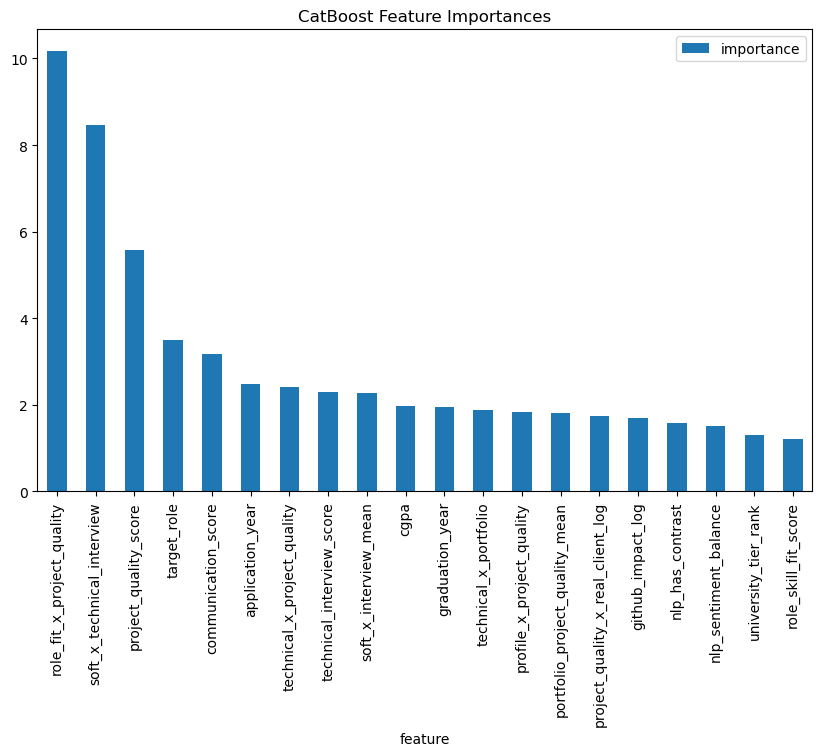

In [39]:
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt

# Hızlı bir baseline model kurun
model = CatBoostRegressor(iterations=500, verbose=0, random_seed=42)
# X_train, y_train'i hazırladığınızı varsayıyoruz
model.fit(X, y, cat_features=cat_cols)

# Özellik önemlerini al
feature_importances = model.get_feature_importance()
feature_names = X.columns

imp_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
imp_df = imp_df.sort_values('importance', ascending=False)

# Önemi 0 veya 0'a çok yakın (örneğin 0.01'den küçük) olanları sil
low_importance_features = imp_df[imp_df['importance'] < 0.01]['feature'].tolist()
print(f"Önemsiz özellik sayısı: {len(low_importance_features)}")

# En önemli 20 özelliği görselleştirin
imp_df.head(20).plot.bar(x='feature', y='importance', figsize=(10,6))
plt.title("CatBoost Feature Importances")
plt.show()

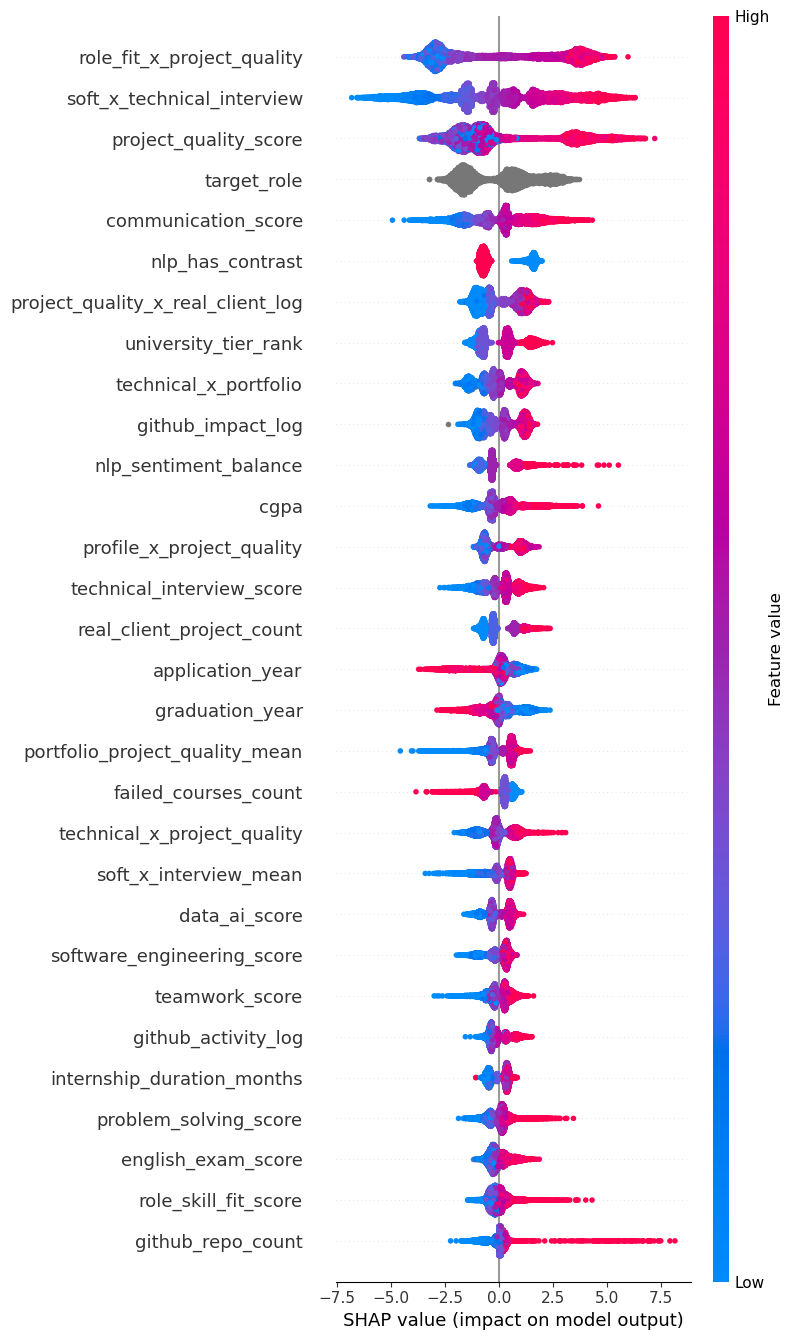

In [40]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Genel bakış grafiği
shap.summary_plot(shap_values, X, max_display=30)

🧹 Özellik Seçimi (Feature Selection) Başlıyor...
✅ 1. Adım: Sıfır varyanslı kolon bulunmadı.
🗑️ 2. Adım: YÜKSEK KORELASYON (>0.95) - 10 kolon siliniyor: ['graduation_year', 'open_source_contribution_count_was_missing', 'age_at_graduation', 'data_ai_score', 'software_engineering_score', 'core_cs_score', 'experience_count_log', 'learning_activity_log', 'applications_without_interview', 'role_fit_x_project_quality']

⏳ 3. Adım: MODEL BAZLI SEÇİM - Hızlı bir CatBoost modeli eğitiliyor...
🗑️ 3. Adım: ÖNEMSİZ ÖZELLİKLER (<0.01) - 24 kolon siliniyor.

🎉 İşlem Tamamlandı! Başlangıçtaki kolon sayısı: 112 -> Kalan kolon sayısı: 78


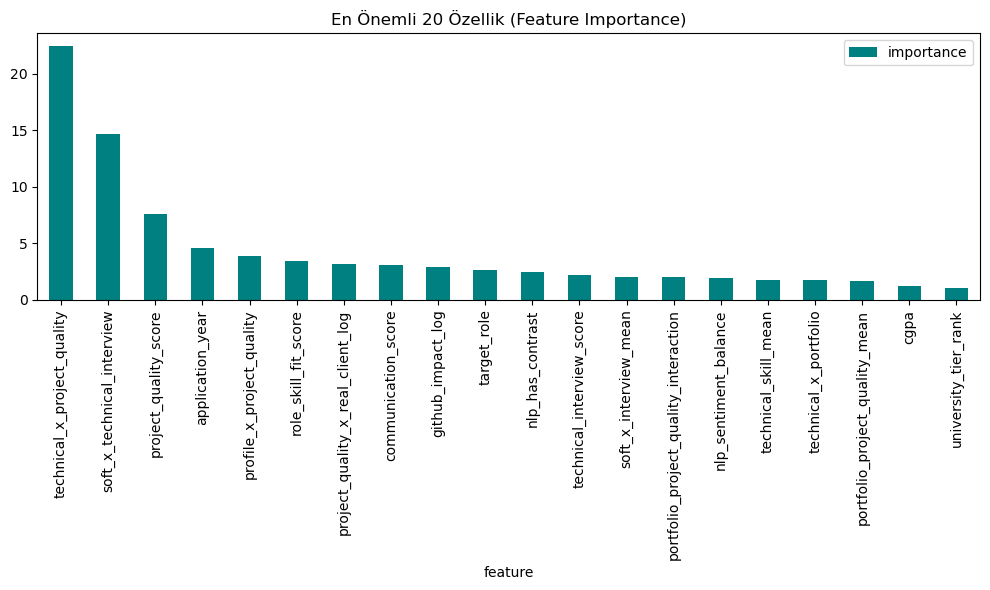

In [41]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt

def perform_feature_selection(train_df, test_df, target_col="career_success_score", 
                              drop_id_cols=["id", "mentor_feedback_text"]):
    print("🧹 Özellik Seçimi (Feature Selection) Başlıyor...\n" + "="*50)
    
    # Kopyalar üzerinden çalışalım ki ana verimiz bozulmasın
    train = train_df.copy()
    test = test_df.copy()
    
    # 1. SIFIR VARYANS KONTROLÜ (Tek tip değer içeren kolonlar)
    nunique = train.nunique()
    zero_variance_cols = nunique[nunique == 1].index.tolist()
    if zero_variance_cols:
        print(f"🗑️ 1. Adım: SIFIR VARYANS - {len(zero_variance_cols)} kolon siliniyor: {zero_variance_cols}")
        train = train.drop(columns=zero_variance_cols)
        test = test.drop(columns=zero_variance_cols)
    else:
        print("✅ 1. Adım: Sıfır varyanslı kolon bulunmadı.")

    # 2. YÜKSEK KORELASYON KONTROLÜ (Birbirini tekrar eden sayısal kolonlar)
    # Sadece sayısal kolonları alalım
    num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c not in drop_id_cols + [target_col]]
    
    corr_matrix = train[num_cols].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Korelasyonu %95'ten büyük olanları bul
    high_corr_cols = [column for column in upper.columns if any(upper[column] > 0.95)]
    if high_corr_cols:
        print(f"🗑️ 2. Adım: YÜKSEK KORELASYON (>0.95) - {len(high_corr_cols)} kolon siliniyor: {high_corr_cols}")
        train = train.drop(columns=high_corr_cols)
        test = test.drop(columns=high_corr_cols)
    else:
        print("✅ 2. Adım: Yüksek korelasyonlu kolon bulunmadı.")

    # 3. CATBOOST FEATURE IMPORTANCE (Modele hiçbir katkısı olmayan kolonlar)
    print("\n⏳ 3. Adım: MODEL BAZLI SEÇİM - Hızlı bir CatBoost modeli eğitiliyor...")
    
    # Hedef ve özellikleri ayır
    features = [c for c in train.columns if c not in drop_id_cols + [target_col]]
    cat_features = [c for c in features if train[c].dtype == "object" or train[c].dtype.name == "category"]
    
    X_train_temp = train[features]
    y_train_temp = train[target_col]
    
    # Hızlı, ezberlemeyi engelleyen sığ bir model
    dummy_model = CatBoostRegressor(
        iterations=300, 
        depth=4, 
        learning_rate=0.05, 
        verbose=0, 
        random_seed=42
    )
    
    dummy_model.fit(X_train_temp, y_train_temp, cat_features=cat_features)
    
    # Önem derecelerini al
    importances = dummy_model.get_feature_importance()
    imp_df = pd.DataFrame({'feature': features, 'importance': importances}).sort_values('importance', ascending=False)
    
    # Katkısı %0.01'den (çok çok düşük) olanları bul
    useless_features = imp_df[imp_df['importance'] < 0.01]['feature'].tolist()
    
    if useless_features:
        print(f"🗑️ 3. Adım: ÖNEMSİZ ÖZELLİKLER (<0.01) - {len(useless_features)} kolon siliniyor.")
        train = train.drop(columns=useless_features)
        test = test.drop(columns=useless_features)
    else:
        print("✅ 3. Adım: Tamamen önemsiz bir kolon bulunmadı.")
        
    print("\n" + "="*50)
    print(f"🎉 İşlem Tamamlandı! Başlangıçtaki kolon sayısı: {train_df.shape[1]} -> Kalan kolon sayısı: {train.shape[1]}")
    
    # Görselleştirme (En önemli 20 özellik)
    plt.figure(figsize=(10, 6))
    imp_df.head(20).plot.bar(x='feature', y='importance', ax=plt.gca(), color='teal')
    plt.title("En Önemli 20 Özellik (Feature Importance)")
    plt.tight_layout()
    plt.show()
    
    return train, test, imp_df

# FONKSİYONU ÇAĞIRMA (NLP ve Feature Engineering bittikten sonra burayı çalıştırın)
# train_df ve test_df yerine NLP'den çıkan final veri setinizin adını yazın (örn: train_df_final)
train_selected, test_selected, importance_df = perform_feature_selection(
    train_df=train_fe, 
    test_df=test_fe, 
    target_col="career_success_score", # Hedef değişkeninizin adı buysa değiştirmeyin
    drop_id_cols=["id", "mentor_feedback_text"] # Eğitimde kullanılmayacak kimlik/metin kolonları
)

In [42]:
train_selected.head()

,application_year,age,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_duration_months,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,career_success_score,mentor_feedback_text,university_tier_rank,technical_skill_mean,technical_skill_std,technical_skill_min,technical_skill_max,cloud_devops_score,role_skill_fit_score,role_fit_minus_technical_mean,soft_skill_mean,soft_skill_std,communication_presentation_mean,project_count_total,portfolio_project_quality_mean,portfolio_project_quality_interaction,project_quality_x_real_client_log,project_quality_x_project_count_log,github_activity_log,github_impact_log,experience_count_total,internship_months_per_internship,internship_experience_log,hackathon_award_rate,hackathon_activity_log,interview_conversion_rate,log_applications_sent,log_interviews_attended,interview_score_mean,interview_score_gap,technical_interview_x_conversion,technical_x_project_quality,technical_x_portfolio,soft_x_technical_interview,soft_x_interview_mean,profile_x_project_quality,mentor_feedback_len,mentor_feedback_word_count,nlp_positive_signal_count,nlp_negative_signal_count,nlp_has_contrast,nlp_sentiment_balance
0,2021,21,Tier 4,3.17,62.54,77.31,0,DevOps Engineer,73.28,71.11,52.91,84.980000,62.710000,71.570000,63.041897,69.952625,81.90,0,11.0,0,0,65.54,18,1.85,10.0,86.58,40.57,50.29,79.83,44.14,62.70,58.84,3,1,24,0,86.78,Proje kalitesi ve makine öğrenimi konusundaki ...,1,70.147169,9.815953,52.91000,84.98,65.234841,65.234841,-4.912328,60.634286,17.191141,69.335,0,63.166667,53.677260,0.000000,0.000000,3.535145,6.389653,7,2.75,3.871201,0.0,0.000000,0.000000,3.218876,0.000000,45.430,-9.72,0.000000,57.450531,45.974455,24.599330,27.546156,53.011140,225,30,1,1,1,0
1,2024,20,Tier 4,3.24,75.10,87.13,3,Backend Developer,63.12,78.90,61.81,37.450740,69.944694,60.830000,64.510000,57.940000,24.68,0,4.0,1,0,54.48,7,1.22,1.0,33.34,82.99,67.43,43.60,22.05,42.32,40.54,2,0,46,5,46.16,Kodlama ve problem çözme becerileri gelişmekte...,1,62.227270,11.118139,37.45074,78.90,64.131565,68.443674,6.216403,44.952857,16.383597,42.070,1,48.183333,13.445664,0.000000,17.106872,2.255493,3.570096,4,4.00,1.609438,0.0,0.693147,0.106383,3.850148,1.791759,75.210,15.56,8.828723,15.357690,33.901417,37.306376,33.809044,12.604076,259,33,0,1,1,-1
2,2024,28,Tier 4,3.00,68.53,95.64,1,Frontend Developer,100.00,86.44,83.62,85.440000,80.580000,96.433149,62.220000,81.750000,78.92,2,0.0,0,0,75.10,4,12.12,2.0,61.37,43.06,20.19,48.62,65.64,47.27,82.56,1,2,46,5,84.08,İleri düzey frontend geliştirme becerileri ile...,1,84.851461,10.685677,62.22000,100.00,74.850000,92.997716,8.146255,53.985714,19.260904,65.590,4,68.756667,59.268920,86.702482,127.016840,3.901569,5.282188,7,0.00,0.000000,0.0,0.000000,0.106383,3.850148,1.791759,31.625,22.87,4.580851,66.964773,63.723447,23.246249,17.072982,49.645941,233,28,2,0,1,2
3,2019,22,Tier 1,2.82,54.85,77.80,2,Backend Developer,99.08,72.15,77.15,89.214871,85.751415,72.860000,73.680000,54.080000,54.93,0,9.0,1,0,82.40,4,2.96,3.0,45.15,32.06,28.00,59.84,3.89,78.69,85.05,2,4,49,7,89.97,Güçlü bir kodlama yeteneği ve backend geliştir...,4,77.050698,12.974625,54.08000,99.08,71.170472,83.532854,6.482155,46.391429,29.890692,72.445,0,53.816667,45.262320,0.000000,0.000000,2.552565,4.371976,8,4.50,2.995732,0.0,0.693147,0.140000,3.912023,2.079442,30.030,4.06,4.488400,42.323949,63.489775,14.873092,13.931346,27.770777,227,29,2,0,1,2
4,2026,22,Tier 3,2.28,72.25,71.97,1,Product Analyst,92.65,91.15,84.51,70.700000,80.620000,86.830000,80.340000,87.560000,72.85

In [ ]:
cat_params = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 2200,
    "learning_rate": 0.025,
    "depth": 6,
    "l2_leaf_reg": 8,
    "random_seed": RANDOM_STATE,
    "od_type": "Iter",
    "od_wait": 180,
    "verbose": 300,
    "allow_writing_files": False
}


In [ ]:
def run_catboost_cv(
    params,
    X,
    y,
    X_test,
    cat_feature_indices,
    n_splits=5,
    seed=RANDOM_STATE
):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y), start=1):
        print(f"\n========== Fold {fold} ==========")

        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = CatBoostRegressor(**params)

        model.fit(
            X_train,
            y_train,
            cat_features=cat_feature_indices,
            eval_set=(X_valid, y_valid),
            use_best_model=True
        )

        valid_pred = model.predict(X_valid)
        oof_preds[valid_idx] = valid_pred

        fold_rmse = mean_squared_error(y_valid, valid_pred) ** 0.5
        fold_scores.append(fold_rmse)

        print(f"Fold {fold} RMSE: {fold_rmse:.5f}")
        print(f"Fold {fold} MSE : {fold_rmse ** 2:.5f}")

        test_preds += model.predict(X_test) / n_splits

    oof_rmse = mean_squared_error(y, oof_preds) ** 0.5
    oof_mse = mean_squared_error(y, oof_preds)

    print("\n========== CV RESULT ==========")
    print(f"Fold RMSE values: {[round(s, 5) for s in fold_scores]}")
    print(f"Mean RMSE: {np.mean(fold_scores):.5f}")
    print(f"Std RMSE : {np.std(fold_scores):.5f}")
    print(f"OOF RMSE : {oof_rmse:.5f}")
    print(f"OOF MSE  : {oof_mse:.5f}")

    return {
        "oof_preds": oof_preds,
        "test_preds": test_preds,
        "fold_scores": fold_scores,
        "oof_rmse": oof_rmse,
        "oof_mse": oof_mse
    }

In [ ]:
catboost_result = run_catboost_cv(
    cat_params,
    X,
    y,
    X_test,
    cat_feature_indices,
    n_splits=5,
    seed=RANDOM_STATE
)

test_preds = catboost_result["test_preds"]
oof_preds = catboost_result["oof_preds"]
